# RETO 4: CLASIFICACION DE FLORES

### Importar librerías

In [2]:
from urllib.request import urlretrieve
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report

### Traer y leer Dataset

In [3]:
irisURL = 'http://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
urlretrieve(irisURL)
df_iris = pd.read_csv(irisURL, sep=',', names=["Largo_Sepalo", "Ancho_Sepalo", "Largo_Petalo", "Ancho_Petalo", "Clase"])
df_iris = df_iris.dropna()

In [ ]:
print(df_iris)
print(df_iris.head())
print(df_iris.tail())

## <span style="color:yellow">K-Nearest Neighbors</span>

### Separar X, y, entrenamiento y pruebas

In [4]:
X_knn = df_iris.drop('Clase', axis=1).copy()
y_knn = df_iris['Clase'].copy()

In [18]:
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X_knn, y_knn, test_size=0.3, random_state=28, stratify=y_knn)

In [19]:
scaler = StandardScaler()

X_train_knn_scaled = scaler.fit_transform(X_train_knn)
X_test_knn_scaled = scaler.transform(X_test_knn)

### Entrenar modelo y predicciones

In [ ]:
knn = KNeighborsClassifier()
knn.fit(X_train_knn_scaled, y_train_knn)

KNeighborsClassifier()

In [21]:
pred_knn = knn.predict(X_test_knn_scaled)

print(pred_knn)

['Iris-setosa' 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa' 'Iris-setosa' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica']


### Validaciones

In [22]:
accuracy_knn = accuracy_score(y_test_knn, pred_knn)
report_knn = classification_report(y_test_knn, pred_knn)

print(f"Precisión de KNN: {accuracy_knn}")
print(f"Reporte de clasificación de KNN:\n{report_knn}")

Precisión de KNN: 0.9333333333333333
Reporte de clasificación de KNN:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.93      0.87      0.90        15
 Iris-virginica       0.88      0.93      0.90        15

       accuracy                           0.93        45
      macro avg       0.93      0.93      0.93        45
   weighted avg       0.93      0.93      0.93        45



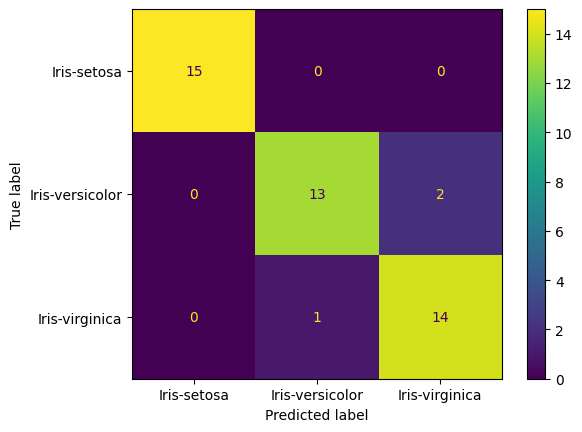

In [23]:
ConfusionMatrixDisplay.from_predictions(y_test_knn, pred_knn)

### Cambiar hiperparametros

In [24]:
param_grid_knn = {
    "n_neighbors": range(1, 21),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5)
grid_knn.fit(X_train_knn_scaled, y_train_knn)

print(f"Mejores hiperparámetros: {grid_knn.best_params_} con precisión realista de: {grid_knn.best_score_}")

Mejores hiperparámetros: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'} con precisión realista de: 0.9714285714285715


## <span style="color:yellow">Gradient Boosting</span>

### Separar X, y, entrenamiento y pruebas

In [25]:
X_gb = df_iris.drop('Clase', axis=1).copy()
y_gb = df_iris['Clase'].copy()

In [26]:
X_train_gb, X_test_gb, y_train_gb, y_test_gb = train_test_split(X_gb, y_gb, test_size=0.3, random_state=28, stratify=y_gb)

### Entrenar modelo y predicciones

In [27]:
gb = GradientBoostingClassifier()
gb.fit(X_train_gb, y_train_gb)

GradientBoostingClassifier()

In [28]:
pred_gb = gb.predict(X_test_gb)

# print(pred_gb)

### Validaciones

In [29]:
accuracy_gb = accuracy_score(y_test_gb, pred_gb)
report_gb = classification_report(y_test_gb, pred_gb)

print(f"Precisión de Gradient Boosting: {accuracy_gb}")
print(f"Reporte de clasificación de Gradient Boosting:\n{report_gb}")

Precisión de Gradient Boosting: 0.9555555555555556
Reporte de clasificación de Gradient Boosting:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.93      0.93      0.93        15
 Iris-virginica       0.93      0.93      0.93        15

       accuracy                           0.96        45
      macro avg       0.96      0.96      0.96        45
   weighted avg       0.96      0.96      0.96        45



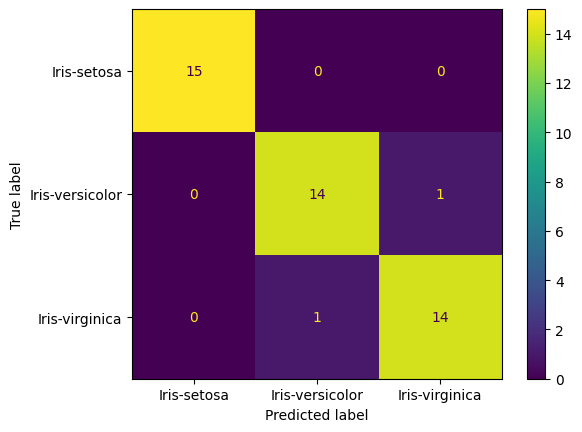

In [30]:
ConfusionMatrixDisplay.from_predictions(y_test_gb, pred_gb)

### Cambiar hiperparametros

In [31]:
param_grid_gb = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [2, 3, 4]
}

grid_gb = GridSearchCV(GradientBoostingClassifier(), param_grid_gb, cv=5)
grid_gb.fit(X_train_gb, y_train_gb)

print(f"Mejores hiperparámetros: {grid_gb.best_params_} con precisión realista de: {grid_gb.best_score_}")


Mejores hiperparámetros: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 50} con precisión realista de: 0.9714285714285715


## <span style="color:red">Conclusiones</span>

<p>De lo obsevado podemos observar lo siguiente:</p>

<ul>
    <li>
        El modelo <strong>K-Nearest Neighbors</strong> en su forma predeterminada con una separación del dataset aleatoria, pudo alcanzar una precisión de 93%, equivocandose en la predicción de tres datos, exactamente, predijo erroneamente flores de las clases Versicolor y Virginica, por lo que podemos inferir que son Clases con características con valores más cercanos que la clase Setosa, como también se puede ver en el reporte de precision, recall y score.
    </li>
    <li>
        Los hiperparametros a cambiar en <strong>K-Nearest Neighbors</strong> son: "n_neighbors" siendo el más importante, permite cambiar el número de vecinos más cercanos que el modelo consulta para clasificar un nuevo punto. Por otro lado, "weights" define como votan los vecinos, pudiendo ser Uniformemente en el que todos tienen el mismo peso o por Distancia en el que los más cercanos valen más. Y por ultimo "metric" que define como se calcula la distancia y su formula, siendo la más popular Euclideana que es una línea recta.
    </li>
    <li>
        El modelo <strong>K-Nearest Neighbors</strong> presenta en su condición predeterminada una precisión de ~93%, y con el promediado que obtuvimos al utilizar GridSearchCV obtuvimos una precisión más realista del modelo aproximadamente ~97% con los mejores hiperparametros, siendo estos: tres vecinos, peso uniforme y metrica euclidiana.
    </li>
    <li>
        El modelo <strong>Gradient Boosting</strong> en su predeterminada obtuvo una precisión de ~95% incluso sin modificar ningun parámetro, indicando que el dataset es relativamente fácil de separar. En estas condiciones, el modelo predice mal dos flores de las clases Virginica y Versicolor, demostrando que estas clases tienen características similares.
    </li>
    <li>
        Para el modelo <strong>Gradient Boosting</strong> los hiperparámetros que se pueden modificar son: "n_estimators" que define la cantidad de árboles, "learning_rate" es para definir cuánto corrige cada árbol, y "max_depth" para establecer la profundidad de cada árbol. Entre más árboles y menos corrección el modelo es más estable y por el contrario tiende más al sobreajuste.
    </li> 
    <li>
        Al modificar los hiperparámetros del modelo <strong>Gradient Boosting</strong> obtenemos una precisión realista de ~97%, y para esto se debió usar "n_estimators" = 50, "learning_rate" = 0.01, y "max_depth" = 2. Lo que implica que se hacen correciones pequeñas de solo 1%, es decir, el aprendizaje es lento, que el modelo es bastante estable, y que es un árbol poco profundo bastante simple.
    </li>
    <li>
        A diferencia del modelo <strong>Bosques Aleatorios</strong> antes visto, que entrena árboles independientes y luego promedia, este nuevo modelo <strong>Gradient Boosting</strong> entre árboles secuencialmente corrigiendo errores previos, es decir, cada nuevo árbol aprende de los errores del anterior, esto reduce sesgo y da mejores resultados.
    </li>
</ul>